# Clase 10 — Analizando el catálogo de Netflix

En este ejercicio asumirás el rol de un **Data Analyst** dentro de Netflix. El equipo de negocio quiere entender mejor cómo está distribuido el catálogo de la plataforma para tomar decisiones sobre futuras inversiones en contenido.

Para ello deberás utilizar las herramientas aprendidas en esta clase:

- `groupby()`
- funciones de agregación
- `agg()`
- `pivot_table()`
- `unstack()`
- gráficos con Pandas y Matplotlib

> No utilices bucles (`for`) para resolver los ejercicios.


## Parte 1: Exploración del dataset

Antes de comenzar el análisis responde:

1. Carga el dataset.
2. Muestra las primeras filas.
3. ¿Cuántas filas y columnas posee?
4. ¿Qué tipo de dato tiene cada columna?
5. ¿Existen valores nulos?
6. ¿Qué columnas presentan mayor cantidad de valores faltantes?

In [2]:
# tú código acá
import pandas as pd 

df = pd.read_csv("netflix_data.csv")

df.head() #primeras filas

df.shape #filas y columnas que posee

df.dtypes #tipo de datos

df.isnull().sum()# valroes nulo?"

df.isnull().sum().sort_values(ascending=False)#6



director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

## Parte 2: Agrupaciones

### Ejercicio 1 - ¿Cuántos títulos existen por país?

Ordena el resultado de mayor a menor.


In [4]:
# tu código acá
df.groupby("country")["title"].count().sort_values(ascending=False)

country
United States          2818
India                   972
United Kingdom          419
Japan                   245
South Korea             199
                       ... 
Australia, Iraq           1
Venezuela                 1
Venezuela, Colombia       1
West Germany              1
, South Korea             1
Name: title, Length: 748, dtype: int64

### Ejercicio 2 - ¿Cuántas películas y cuántas series tiene Netflix?

In [5]:
# tu código acá
df.groupby("type")["title"].count()

type
Movie      6131
TV Show    2676
Name: title, dtype: int64

### Ejercicio 3 - ¿Cuántos títulos fueron lanzados cada año?

Ordena el resultado cronológicamente.


In [8]:
# tu código acá
df.groupby("release_year")["title"].count()

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: title, Length: 74, dtype: int64

### Ejercicio 4 - ¿Cuál es la clasificación por edades más frecuente?

Por ejemplo:

- TV-MA
- TV-14
- PG
- R

In [9]:
# tu código acá
df["rating"].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

### Ejercicio 5 - Obtén para cada tipo de contenido (Movie y TV Show):

- cantidad de títulos
- año promedio de lanzamiento
- año más reciente
- año más antiguo

> Utiliza **agg()**.

In [10]:
# tu código acá
df.groupby("type").agg({
    "title": "count",
    "release_year": ["mean", "max", "min"]
})

title release_year            
        count         mean   max   min
type                                  
Movie    6131  2013.121514  2021  1942
TV Show  2676  2016.605755  2021  1925

## Parte 3: Agrupaciones múltiples

### Ejercicio 6 - Obtén la cantidad de títulos para cada combinación.

Agrupa por:

- país
- tipo de contenido

In [11]:
# tu código acá
df.groupby(["country", "type"])["title"].count()

country                                              type   
, France, Algeria                                    Movie       1
, South Korea                                        TV Show     1
Argentina                                            Movie      38
                                                     TV Show    18
Argentina, Brazil, France, Poland, Germany, Denmark  Movie       1
                                                                ..
Venezuela                                            Movie       1
Venezuela, Colombia                                  Movie       1
Vietnam                                              Movie       7
West Germany                                         Movie       1
Zimbabwe                                             Movie       1
Name: title, Length: 847, dtype: int64

### Ejercicio 7 - Convierte el resultado anterior en una tabla donde:

- las filas sean los países
- las columnas sean Movie y TV Show

> Utiliza **unstack()**.

In [12]:
# tu código acá
df.groupby(["country", "type"])["title"].count().unstack()

type,Movie,TV Show
country,,
", France, Algeria",1.0,NaN
", South Korea",NaN,1.0
Argentina,38.0,18.0
"Argentina, Brazil, France, Poland, Germany, Denmark",1.0,NaN
"Argentina, Chile",2.0,NaN
...,...,...
Venezuela,1.0,NaN
"Venezuela, Colombia",1.0,NaN
Vietnam,7.0,NaN


## Parte 4: Tablas dinámicas

### Ejercicio 8 - Construye una tabla dinámica donde:

- filas → país
- columnas → tipo de contenido
- valores → cantidad de títulos

In [13]:
# tu código acá
df.pivot_table(
    index="country",
    columns="type",
    values="title",
    aggfunc="count"
)

type,Movie,TV Show
country,,
", France, Algeria",1.0,NaN
", South Korea",NaN,1.0
Argentina,38.0,18.0
"Argentina, Brazil, France, Poland, Germany, Denmark",1.0,NaN
"Argentina, Chile",2.0,NaN
...,...,...
Venezuela,1.0,NaN
"Venezuela, Colombia",1.0,NaN
Vietnam,7.0,NaN


### Ejercicio 9 - Construye otra tabla dinámica donde:

- filas → clasificación por edades
- columnas → tipo de contenido
- valores → cantidad de títulos

In [14]:
# tu código acá
df.pivot_table(
    index="rating",
    columns="type",
    values="title",
    aggfunc="count"
)

type,Movie,TV Show
rating,,
66 min,1.0,NaN
74 min,1.0,NaN
84 min,1.0,NaN
G,41.0,NaN
NC-17,3.0,NaN
NR,75.0,5.0
PG,287.0,NaN
PG-13,490.0,NaN
R,797.0,2.0


### Ejercicio 10 - Modifica la tabla dinámica para que los valores faltantes aparezcan como **0**.

In [15]:
# tu código acá
df.pivot_table(
    index="rating",
    columns="type",
    values="title",
    aggfunc="count",
    fill_value=0
)

type,Movie,TV Show
rating,,
66 min,1,0
74 min,1,0
84 min,1,0
G,41,0
NC-17,3,0
NR,75,5
PG,287,0
PG-13,490,0
R,797,2


## Parte 5: Visualización

### Ejercicio 11 - Genera un gráfico de barras con el **Top 10 países con mayor cantidad de títulos**.

El gráfico debe incluir:

- título
- tamaño de figura
- etiquetas rotadas
- eje Y con nombre


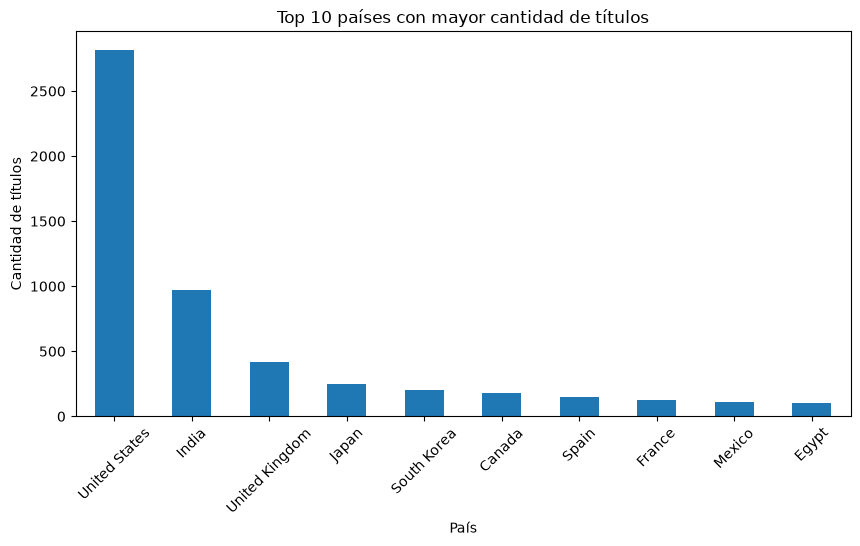

In [21]:
# tu código acá
import matplotlib.pyplot as plt

top10 = df["country"].value_counts().head(10)

plt.figure(figsize=(10,5))
top10.plot(kind="bar")

plt.title("Top 10 países con mayor cantidad de títulos")
plt.xlabel("País")
plt.ylabel("Cantidad de títulos")
plt.xticks(rotation=45)

plt.show()

### Ejercicio 12 - Genera un gráfico de barras mostrando la cantidad de:

- Movies
- TV Shows

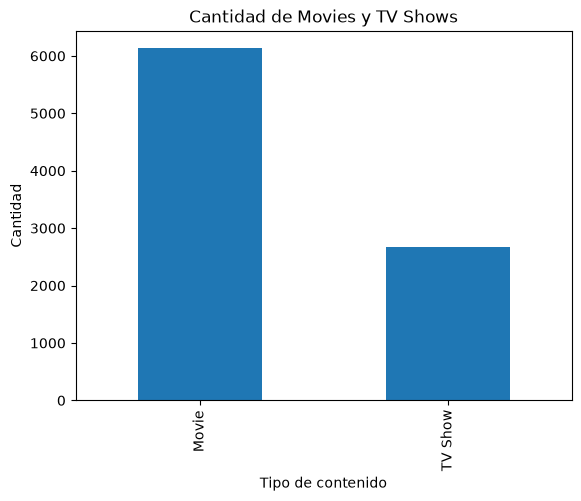

In [22]:
# tu código acá
df["type"].value_counts().plot(kind="bar")

plt.title("Cantidad de Movies y TV Shows")
plt.xlabel("Tipo de contenido")
plt.ylabel("Cantidad")

plt.show()

### Ejercicio 13 - Utilizando la tabla dinámica, crea un gráfico de barras agrupadas que compare películas y series por país.


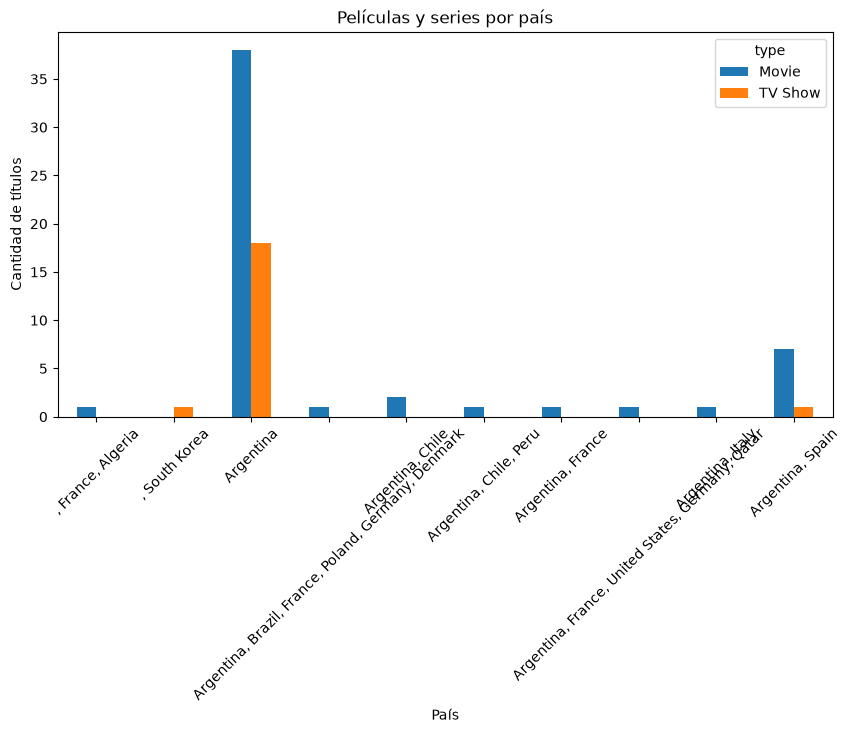

In [24]:
# tu código acá
tabla = df.pivot_table(
    index="country",
    columns="type",
    values="title",
    aggfunc="count",
    fill_value=0
)

tabla.head(10).plot(kind="bar", figsize=(10,5))

plt.title("Películas y series por país")
plt.xlabel("País")
plt.ylabel("Cantidad de títulos")
plt.xticks(rotation=45)

plt.show()

## Parte 6: Análisis

Redacta al menos **cinco insights** basados en el análisis realizado. Algunas preguntas que puedes responder son:

- ¿Qué país domina el catálogo?
- ¿Netflix posee más películas o más series?
- ¿Qué clasificación por edades es la más utilizada?
- ¿Existen países donde predominen las series?
- ¿Qué tendencia observas respecto al año de lanzamiento de los contenidos?

Justifica cada respuesta utilizando los datos obtenidos.

In [ ]:
# tu código acá

## Desafío

Netflix desea aumentar su presencia en Latinoamérica. Analiza únicamente los siguientes países:

- Argentina
- Brasil
- Chile
- Colombia
- México
- Perú

Responde:

1. ¿Cuál aporta mayor cantidad de contenido?
2. ¿Predominan las películas o las series?
3. ¿Qué clasificación por edades es la más común?
4. Genera un gráfico comparativo.
5. Escribe una breve recomendación para el director regional de Netflix basada en tus resultados.


In [ ]:
# tu código acá